<a href="https://colab.research.google.com/github/harshitschooled/AI-ML-Internship/blob/main/Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)
    print("Files:", len(files))
    print("-"*50)

/content/dataset
Files: 0
--------------------------------------------------
/content/dataset/brain_tumor_dataset
Files: 0
--------------------------------------------------
/content/dataset/brain_tumor_dataset/no
Files: 0
--------------------------------------------------


In [5]:
import zipfile

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Total files in zip:", len(z.namelist()))
    print("\nFirst 20 entries:")
    print("\n".join(z.namelist()[:20]))

Total files in zip: 506

First 20 entries:
brain_tumor_dataset/no/1 no.jpeg
brain_tumor_dataset/no/10 no.jpg
brain_tumor_dataset/no/11 no.jpg
brain_tumor_dataset/no/12 no.jpg
brain_tumor_dataset/no/13 no.jpg
brain_tumor_dataset/no/14 no.jpg
brain_tumor_dataset/no/15 no.jpg
brain_tumor_dataset/no/17 no.jpg
brain_tumor_dataset/no/18 no.jpg
brain_tumor_dataset/no/19 no.jpg
brain_tumor_dataset/no/2 no.jpeg
brain_tumor_dataset/no/20 no.jpg
brain_tumor_dataset/no/21 no.jpg
brain_tumor_dataset/no/22 no.jpg
brain_tumor_dataset/no/23 no.jpg
brain_tumor_dataset/no/24 no.jpg
brain_tumor_dataset/no/25 no.jpg
brain_tumor_dataset/no/26 no.jpg
brain_tumor_dataset/no/27 no.jpg
brain_tumor_dataset/no/28 no.jpg


In [9]:
print("X exists:", 'X' in globals())
print("y exists:", 'y' in globals())

X exists: False
y exists: False


In [11]:
import zipfile

with zipfile.ZipFile('/content/archive (21).zip', 'r') as z:
    print("Files:", len(z.namelist()))

    # Test reading one image
    data = z.read(z.namelist()[0])

print("Successfully read image bytes")

Files: 506
Successfully read image bytes


In [12]:
import zipfile
import cv2
import numpy as np
from skimage.feature import hog

X = []
y = []

with zipfile.ZipFile('/content/archive (21).zip', 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for file in image_files:

        img_bytes = z.read(file)

        img = cv2.imdecode(
            np.frombuffer(img_bytes, np.uint8),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        X.append(features)

        if '/yes/' in file:
            y.append(1)
        else:
            y.append(0)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Tumor:", np.sum(y==1))
print("No Tumor:", np.sum(y==0))

X shape: (506, 8100)
y shape: (506,)
Tumor: 155
No Tumor: 351


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    C=10,
    gamma='scale'
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4411764705882353
              precision    recall  f1-score   support

           0       0.61      0.54      0.57        71
           1       0.17      0.23      0.20        31

    accuracy                           0.44       102
   macro avg       0.39      0.38      0.38       102
weighted avg       0.48      0.44      0.46       102



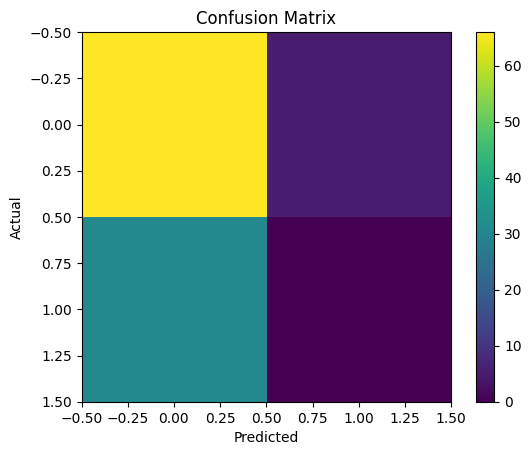

[[66  5]
 [31  0]]


In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)

In [16]:
import zipfile
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

X = []
y = []

with zipfile.ZipFile('/content/archive (21).zip', 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    ]

    for file in image_files:

        img_bytes = z.read(file)

        img = cv2.imdecode(
            np.frombuffer(img_bytes, np.uint8),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(img, (64,64))
        img = img / 255.0

        X.append(img.flatten())

        if '/yes/' in file:
            y.append(1)
        else:
            y.append(0)

X = np.array(X)
y = np.array(y)

print(X.shape)

(506, 4096)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4117647058823529
              precision    recall  f1-score   support

           0       0.58      0.59      0.58        71
           1       0.00      0.00      0.00        31

    accuracy                           0.41       102
   macro avg       0.29      0.30      0.29       102
weighted avg       0.40      0.41      0.41       102

[[42 29]
 [31  0]]


In [24]:
```python
# ============================================================
# BRAIN TUMOR DETECTION USING CNN
# ============================================================

import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# LOAD DATASET FROM ZIP
# ============================================================

X = []
y = []

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    print("Total Images:", len(image_files))

    for file in image_files:

        try:
            img_bytes = z.read(file)

            img = cv2.imdecode(
                np.frombuffer(img_bytes, np.uint8),
                cv2.IMREAD_COLOR
            )

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            img = img.astype("float32") / 255.0

            X.append(img)

            if "/yes/" in file:
                y.append(1)
            else:
                y.append(0)

        except:
            continue

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nClass Distribution")
print("No Tumor :", np.sum(y == 0))
print("Tumor    :", np.sum(y == 1))

# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(X[i])

    if y[i] == 1:
        plt.title("Tumor")
    else:
        plt.title("No Tumor")

    plt.axis("off")

plt.show()

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

# ============================================================
# DATA AUGMENTATION
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.10,
    horizontal_flip=True
)

datagen.fit(X_train)

# ============================================================
# CLASS WEIGHTS
# ============================================================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("\nClass Weights:")
print(class_weights)

# ============================================================
# CNN MODEL
# ============================================================

model = Sequential([

    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

# ============================================================
# EVALUATION
# ============================================================

pred_prob = model.predict(X_test)

y_pred = (pred_prob > 0.5).astype(int)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

print("\nConfusion Matrix:")
print(cm)

# ============================================================
# SAVE MODEL
# ============================================================

model.save("brain_tumor_cnn_model.keras")

print("\nModel Saved Successfully!")

# ============================================================
# PREDICT NEW MRI IMAGE
# ============================================================

def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (128,128))
    img = img.astype("float32") / 255.0

    img = np.expand_dims(img, axis=0)

    prob = model.predict(img, verbose=0)[0][0]

    print("Tumor Probability:", round(float(prob), 4))

    if prob > 0.5:
        print("Brain Tumor Detected")
    else:
        print("No Brain Tumor")

# Example:
# predict_image("/content/test.jpg")
```


SyntaxError: invalid syntax (1144782672.py, line 1)

Total Images: 506
Dataset Shape: (506, 128, 128, 3)
Labels Shape: (506,)
No Tumor: 351
Tumor: 155
Class Weights: {0: 0.7214285714285714, 1: 1.6290322580645162}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6262 - loss: 0.6970 - val_accuracy: 0.3333 - val_loss: 0.6943
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4579 - loss: 0.6924 - val_accuracy: 0.3039 - val_loss: 0.7042
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4851 - loss: 0.6885 - val_accuracy: 0.6961 - val_loss: 0.6717
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6436 - loss: 0.6930 - val_accuracy: 0.5098 - val_loss: 0.6931
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5371 - loss: 0.6833 - val_accuracy: 0.6961 - val_loss: 0.6519
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5817 - loss: 0.6825 - val_accuracy: 0.7157 - val_loss: 0.6150
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6213 - loss: 0.6783 - val_accuracy: 0.6275 - val_loss: 0.6520
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4975 - loss: 0.6803 - val_accuracy: 0.6471 - val_loss:

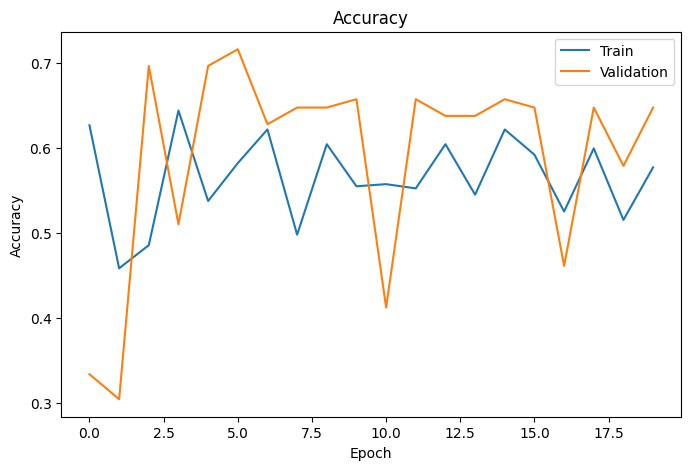

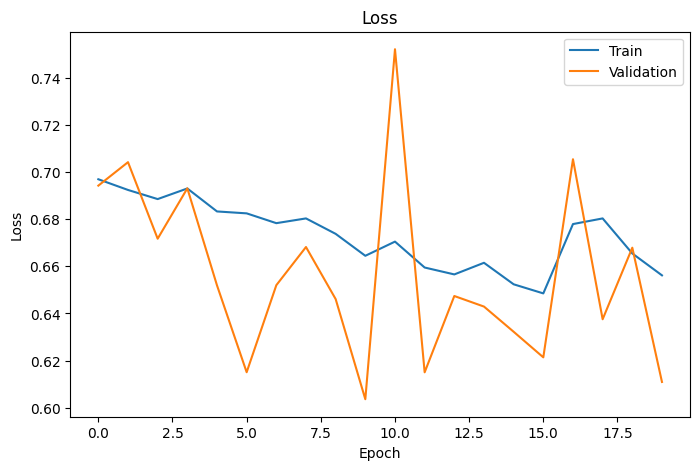

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step

Accuracy:
0.6470588235294118

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.63      0.71        71
           1       0.45      0.68      0.54        31

    accuracy                           0.65       102
   macro avg       0.63      0.66      0.63       102
weighted avg       0.71      0.65      0.66       102


Confusion Matrix:
[[45 26]
 [10 21]]


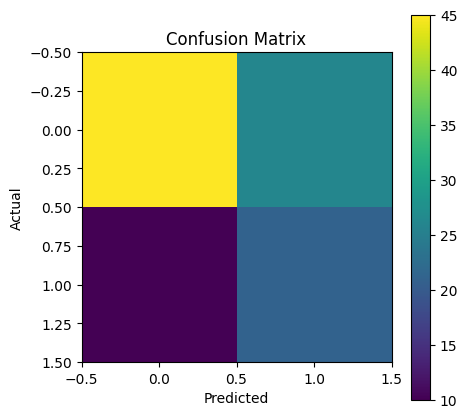

Model saved successfully!


In [25]:
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================
# LOAD DATASET FROM ZIP
# ==========================

X = []
y = []

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    print("Total Images:", len(image_files))

    for file in image_files:

        try:
            img_bytes = z.read(file)

            img = cv2.imdecode(
                np.frombuffer(img_bytes, np.uint8),
                cv2.IMREAD_COLOR
            )

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            img = img.astype(np.float32) / 255.0

            X.append(img)

            if "/yes/" in file:
                y.append(1)
            else:
                y.append(0)

        except Exception:
            continue

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

print("No Tumor:", np.sum(y == 0))
print("Tumor:", np.sum(y == 1))

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# DATA AUGMENTATION
# ==========================

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# ==========================
# CLASS WEIGHTS
# ==========================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class Weights:", class_weights)

# ==========================
# CNN MODEL
# ==========================

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================
# TRAIN
# ==========================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

# ==========================
# ACCURACY GRAPH
# ==========================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# ==========================
# LOSS GRAPH
# ==========================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# ==========================
# EVALUATION
# ==========================

pred_prob = model.predict(X_test)

y_pred = (pred_prob > 0.5).astype(int)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================
# SAVE MODEL
# ==========================

model.save("brain_tumor_cnn_model.keras")

print("Model saved successfully!")

# ==========================
# PREDICT NEW IMAGE
# ==========================

def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (128,128))
    img = img.astype(np.float32) / 255.0

    img = np.expand_dims(img, axis=0)

    prob = model.predict(img, verbose=0)[0][0]

    print("Tumor Probability:", prob)

    if prob > 0.5:
        print("Brain Tumor Detected")
    else:
        print("No Brain Tumor")

# Example:
# predict_image("/content/test.jpg")

In [21]:
import numpy as np

print("No Tumor:", np.sum(y == 0))
print("Tumor:", np.sum(y == 1))


No Tumor: 351
Tumor: 155


In [26]:
print(cm)

[[45 26]
 [10 21]]
